## Description

In this competition, participants will work with four datasets: training, validation, test, and comp_test. The training dataset contains labeled data that competitors will use to train their models. The validation dataset allows them to fine-tune their models and assess performance during development. The test dataset provides an additional benchmark to estimate how well their models generalize to unseen data. However, the comp_test dataset is different—it consists of unlabeled data for which participants must generate predictions. Their final task is to submit predictions for this dataset, which will be evaluated against hidden ground-truth labels to determine the competition rankings.

In [1]:
#Import deep learning libraries


import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split, Subset, Dataset
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np
from PIL import Image
import time
from tqdm import tqdm

import matplotlib.pyplot as plt
import os

# **Step 1: Competition Data Curation and Preprocessing** 

## Image Preprocessing Pipeline

The transformation pipeline is designed to preprocess images before feeding them into a machine learning model. The steps involved are:

1. **Convert to Grayscale**:  
   `transforms.Grayscale(num_output_channels=1)` ensures all images have a single channel, simplifying processing for models that do not require color information.

2. **Resize to a Fixed Dimension**:  
   `transforms.Resize((150, 150))` resizes all images to a standard size of **150x150 pixels**, ensuring consistency across the dataset.

3. **Convert to Tensor**:  
   `transforms.ToTensor()` converts images into **PyTorch tensors**, normalizing pixel values to the `[0,1]` range.

4. **Normalize Pixel Values**:  
   `transforms.Normalize(mean=[0.5], std=[0.5])` standardizes pixel values to have a **zero mean** and a range approximately from `[-1,1]`. This helps stabilize training and improve model performance.

This preprocessing ensures uniformity across the dataset and enhances the model’s ability to learn meaningful features.

In [2]:
# Define the transformations
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  # Convert to grayscale
    transforms.Resize((150, 150)),                # Resize images to 150x150
    transforms.ToTensor(),                        # Convert images to tensors
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to approximately [-1, 1]
])

## Training Dataset Preparation

1. **Define the Training Dataset Path**:  
   The dataset is stored in the directory `/kaggle/input/intel-image-classification/seg_train/seg_train`, which contains images organized into subfolders representing different classes.

2. **Load the Dataset Using `ImageFolder`**:  
   `datasets.ImageFolder(root=train_path, transform=transform)` automatically assigns labels based on subfolder names and applies the predefined transformations.

3. **Define the Batch Size**:  
   A `batch_size` of `32` is set, meaning the model will process 32 images at a time during training.

4. **Create the DataLoader**:  
   `DataLoader(train_dataset, batch_size=batch_size, shuffle=True)` creates an iterable that loads data in mini-batches. The `shuffle=True` ensures that the dataset is randomly shuffled at each epoch, improving generalization and preventing overfitting.

This setup enables efficient data loading, ensuring that images are properly processed and fed into the model during training.

In [3]:
train_path = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train'

train_dataset = datasets.ImageFolder(root=train_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

class_names = train_dataset.classes
idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

print(f"Number of training samples: {len(train_dataset)}")
print(f"Classes: {class_names}")

Number of training samples: 14034
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


## Visualizing Sample Images from the Training Dataset

This block of code retrieves a batch of images from the `train_loader`, denormalizes them, and plots a subset to visually inspect the dataset.

### **Steps:**
1. **Iterate Over the DataLoader**:  
   The loop extracts a batch of `images` and their corresponding `labels` from the `train_loader`.

2. **Denormalize the Images**:  
   Since the dataset was normalized using `mean=[0.5], std=[0.5]`, the images are denormalized using `images = images * 0.5 + 0.5`, bringing pixel values back to their original scale `[0,1]` for correct visualization.

3. **Plot the Images**:  
   - `plt.figure(figsize=(10, 10))` sets the figure size.
   - A loop runs 9 times to plot the first 9 images.
   - `plt.imshow(images[i][0], cmap='gray')` ensures grayscale images are displayed correctly.
   - `plt.title(f"Label: {labels[i].item()}")` assigns a title with the corresponding label.
   - `plt.axis('off')` removes axis ticks for better visualization.

4. **Show the Images and Stop the Loop**:  
   The `break` statement ensures that only the first batch of images is displayed.

This visualization step helps in understanding the dataset distribution and verifying preprocessing transformations before training the model.


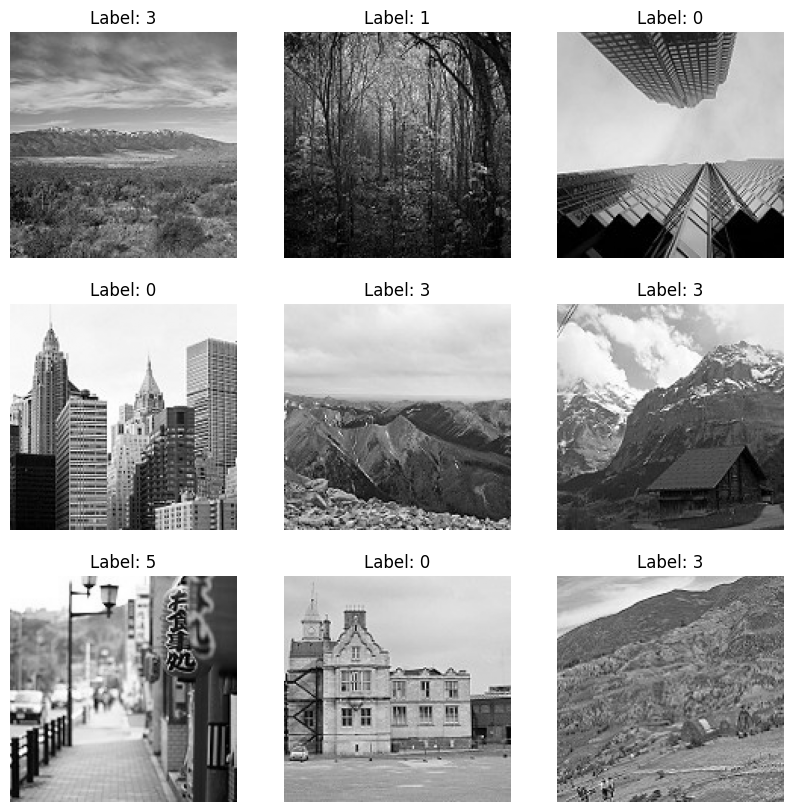

In [4]:
# Check some examples
for images, labels in train_loader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break

## Preparing Validation and Test Datasets with Stratified Sampling

In this section, we load the validation dataset, apply stratified sampling to ensure class balance, and create separate **validation** and **test** datasets.

### **Steps:**

1. **Load the Full Validation Dataset**:  
   - The dataset is located at `'/kaggle/input/intel-image-classification/seg_test/seg_test'`.
   - `datasets.ImageFolder(root=val_path, transform=transform)` loads the dataset and applies the same transformations used for training.
   - `val_dataset_full.targets` contains the class labels, which are converted into a NumPy array for stratified sampling.

2. **Perform Stratified Sampling**:  
   - `StratifiedShuffleSplit(n_splits=num_iterations, test_size=sample_size, random_state=42)` ensures that each subset maintains the same class distribution as the full dataset.
   - `num_iterations=2` creates two non-overlapping samples: one for **validation** and one for **testing**.
   - The loop iterates through the splits and extracts indices for the validation and test subsets.

3. **Assign the Samples to Validation and Test Sets**:  
   - The first sample (`sample_datasets[0]`) is used as the **validation dataset**.
   - The second sample (`sample_datasets[1]`) is used as the **test dataset**.

4. **Create DataLoaders**:  
   - The `DataLoader` is used to efficiently load data in batches.
   - A batch size of `100` is set.
   - `shuffle=False` ensures that the order remains consistent, preserving the stratified class distribution.

### **Purpose of This Approach**:
- Stratified sampling ensures that both validation and test datasets **maintain the original class distribution**, avoiding potential class imbalance issues.
- The validation dataset helps fine-tune the model, while the test dataset provides a final unbiased evaluation.

This setup ensures a fair and balanced model assessment before deploying it on unseen competition data.

In [5]:
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
from torchvision import datasets

# Validation and test data
val_path = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test'

# Load the full validation dataset using the same transform pipeline
val_dataset_full = datasets.ImageFolder(root=val_path, transform=transform)

targets = np.array(val_dataset_full.targets)  # Labels for stratification
sample_size = 100  # Number of samples for each subset
num_iterations = 2  # One split for validation and one for test

# Create stratified sampled subsets
splitter = StratifiedShuffleSplit(n_splits=num_iterations, test_size=sample_size, random_state=42)

sample_datasets = []
for _, sample_idx in splitter.split(np.zeros(len(targets)), targets):
    sample_datasets.append(Subset(val_dataset_full, sample_idx))

val_dataset = sample_datasets[0]
test_dataset = sample_datasets[1]

# Create DataLoaders
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Full validation dataset size: {len(val_dataset_full)}")
print(f"Validation subset size: {len(val_dataset)}")
print(f"Test subset size: {len(test_dataset)}")

Full validation dataset size: 3000
Validation subset size: 100
Test subset size: 100


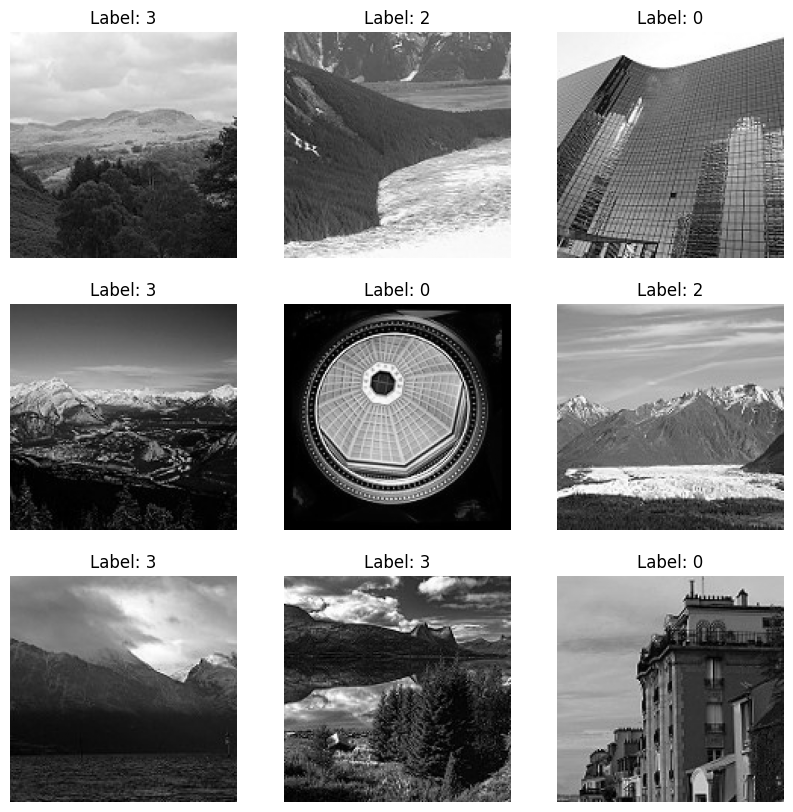

In [6]:
# Check some examples of the validation data
for images, labels in val_loader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break

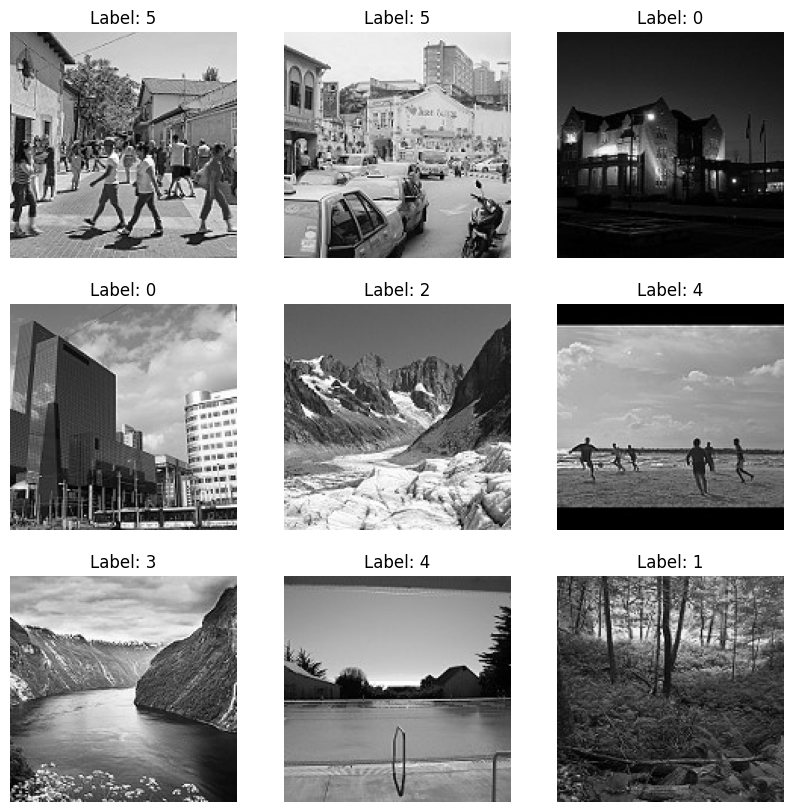

In [7]:
# Check some examples of the test data
for images, labels in test_loader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break

## Preparing the Competition Test Dataset

This section creates a dataset for the **competition test data** (`comp_test`), which consists of **unlabeled images**. The goal is to prepare these images for inference so that participants can generate predictions.

### **Steps:**

1. **List Image Files in the Directory**:  
   - The directory `'/kaggle/input/intel-image-classification/seg_pred/seg_pred'` contains the competition test images.
   - `os.listdir(image_directory)` retrieves all filenames from the directory.
   - The list is **filtered** to include only valid image file formats (`.png`, `.jpg`, `.jpeg`, `.gif`, `.bmp`).

2. **Select a Subset of Images**:  
   - The first `200` images are selected for inference using `image_files[:200]`.  
   - This ensures a manageable dataset size for predictions.

3. **Define a Custom Dataset (`SelectedFilesDataset`)**:  
   - A PyTorch `Dataset` is created to handle only the selected images.
   - It takes the **root directory** and **list of filenames** as inputs.
   - In `__getitem__`, it loads each image using `PIL.Image.open()` and converts it to **RGB** format.
   - If transformations (`transform`) are provided, they are applied before returning the image and its filename.

4. **Create the DataLoader**:  
   - `DataLoader(comp_test_dataset, batch_size=100, shuffle=False)` efficiently loads i


In [8]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader

# Competition / prediction images path
image_directory = '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_pred/seg_pred'

# List image files
image_files = os.listdir(image_directory)

# Keep only image files
image_files = [f for f in image_files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif'))]

# Optional: sort files for reproducible order
image_files = sorted(image_files)

# Select the first 200 images
image_files = image_files[:200]

class SelectedFilesDataset(Dataset):
    def __init__(self, root_dir, file_names, transform=None):
        self.root_dir = root_dir
        self.file_names = file_names
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        file_name = self.file_names[idx]
        file_path = os.path.join(self.root_dir, file_name)

        image = Image.open(file_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, file_name

# Dataset and DataLoader
comp_test_dataset = SelectedFilesDataset(
    root_dir=image_directory,
    file_names=image_files,
    transform=transform
)

comp_test_loader = DataLoader(comp_test_dataset, batch_size=32, shuffle=False)

print(f"Number of competition images: {len(comp_test_dataset)}")
print(f"First 5 files: {image_files[:5]}")

Number of competition images: 200
First 5 files: ['10004.jpg', '10005.jpg', '10012.jpg', '10013.jpg', '10017.jpg']


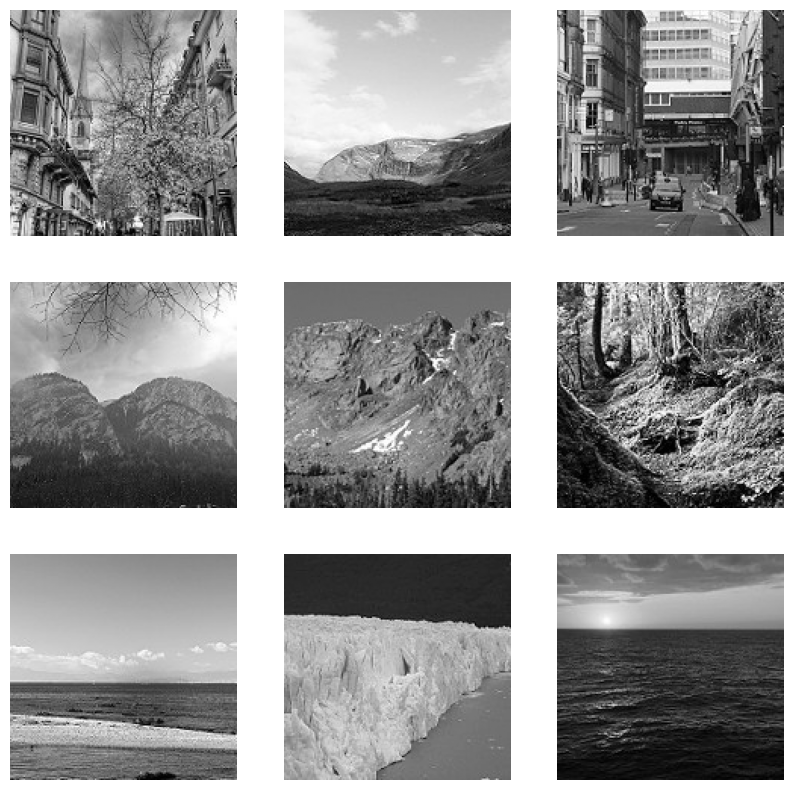

In [9]:
# Check some examples of the competition test data
for images, labels in comp_test_loader:
    # Denormalize the images for plotting
    images = images * 0.5 + 0.5

    # Plot the images
    plt.figure(figsize=(10, 10))
    for i in range(9):  # Plot 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i][0], cmap='gray')  # images[i][0] for grayscale images
        #plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')
    plt.show()
    break

## **Step 2: Model Training Setup**

This step focuses on defining the **deep learning model**, setting up the **loss function**, **optimizer**, and establishing the **training loop**.

### **Define the Model Architecture**
A simple feed forward deep learning model is created for image classification. The architecture should be appropriate for the dataset, considering its complexity and number of classes.


In [10]:
# Check if CUDA is available and set the device accordingly
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define the number of input features and output classes
n_features = 150 * 150  # 22500
n_classes = 6

# Define a simple fully connected neural network (MLP)
class SimpleMLP(torch.nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Initialize the network
net = SimpleMLP(n_features, n_classes).to(device)
print(net)


Using device: cuda
SimpleMLP(
  (net): Sequential(
    (0): Linear(in_features=22500, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=6, bias=True)
  )
)


### **2. Define the Loss Function and Optimizer**
- The **loss function** (e.g., `CrossEntropyLoss`) measures how well the model's predictions match the true labels.
- The **optimizer** (e.g.,`SGD`) updates the model’s parameters to minimize the loss.

In [11]:
# Loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)

# Training configuration
epochs = 10

### **3. Training Loop**
The model is trained iteratively using:
1. **Forward pass** – The model makes predictions.
2. **Loss computation** – The difference between predictions and actual labels is calculated.
3. **Backward pass** – Gradients are computed via backpropagation.
4. **Parameter update** – The optimizer updates model weights to minimize loss.
5. **Evaluation on the validation set** – The model’s performance is monitored to avoid overfitting.

In [12]:
# Training loop
train_losses = []

for epoch in range(epochs):
    net.train()
    running_loss = 0.0
    total_samples = 0

    for images, labels in train_loader:
        # Flatten images: [batch_size, 1, 150, 150] -> [batch_size, 22500]
        X = images.view(images.size(0), -1).to(device)
        y = labels.to(device)

        # Forward pass
        outputs = net(X)
        loss = criterion(outputs, y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Accumulate loss
        batch_size_current = images.size(0)
        running_loss += loss.item() * batch_size_current
        total_samples += batch_size_current

    epoch_loss = running_loss / total_samples
    train_losses.append(epoch_loss)
    print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}")

Epoch [1/10] - Loss: 1.4643
Epoch [2/10] - Loss: 1.3128
Epoch [3/10] - Loss: 1.2269
Epoch [4/10] - Loss: 1.1362
Epoch [5/10] - Loss: 1.0365
Epoch [6/10] - Loss: 0.9392
Epoch [7/10] - Loss: 0.8492
Epoch [8/10] - Loss: 0.7620
Epoch [9/10] - Loss: 0.6854
Epoch [10/10] - Loss: 0.6089


### **4. Model Evaluation on Test Set**

After training, the model's performance is assessed on the test dataset to evaluate its generalization to unseen data. This involves computing the loss and accuracy without updating model parameters, ensuring an unbiased estimate of its predictive capabilities.

In [13]:
# Evaluation helpers
@torch.no_grad()
def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0

    for images, labels in data_loader:
        X = images.view(images.size(0), -1).to(device)
        y = labels.to(device)

        outputs = model(X)
        preds = outputs.argmax(dim=1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return correct / total if total > 0 else 0.0

val_accuracy = evaluate_accuracy(net, val_loader, device)
test_accuracy = evaluate_accuracy(net, test_loader, device)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Validation Accuracy: 0.5400
Test Accuracy: 0.5300


### **5. Generating Predictions for the Competition Test Set**

After training and validating the model, the next step is to generate predictions for the comp_test dataset, which contains unlabeled data. This involves processing the dataset through the trained model to obtain predicted labels. These predictions are then formatted according to the competition's submission requirements, a CSV file with each image's filename and its corresponding predicted label. This submission file is then uploaded to the competition platform for evaluation against the hidden ground-truth labels.

In [14]:
# Generate predictions for the competition test set
preds = []
ids = []
prediction_results = []

net.eval()
with torch.no_grad():
    for images, names in comp_test_loader:
        X = images.view(images.shape[0], -1).to(device)

        # Forward pass
        outputs = net(X)
        predicted = outputs.argmax(dim=1)

        predicted_indices = predicted.detach().cpu().numpy().tolist()
        predicted_labels = [idx_to_class[idx] for idx in predicted_indices]

        ids.extend(list(names))
        preds.extend(predicted_labels)
        prediction_results.extend(list(zip(names, predicted_labels)))

# Preview predictions as a list of (filename, predicted_label)
prediction_results[:10]

[('10004.jpg', 'buildings'),
 ('10005.jpg', 'sea'),
 ('10012.jpg', 'street'),
 ('10013.jpg', 'buildings'),
 ('10017.jpg', 'sea'),
 ('10021.jpg', 'mountain'),
 ('1003.jpg', 'sea'),
 ('10034.jpg', 'glacier'),
 ('10038.jpg', 'mountain'),
 ('10040.jpg', 'mountain')]

In [15]:
import pandas as pd

# Ensure file_names and predictions have the same length
if len(ids) != len(preds):
    raise ValueError("The length of ids and preds must be the same.")

# Create a DataFrame from the file_names and predicted labels
df = pd.DataFrame({
    'id': ids,
    'predicted_label': preds
})

# Define the CSV file name
csv_file = 'predictions.csv'

# Save the DataFrame to a CSV file
df.to_csv(csv_file, index=False)

print(f"CSV file '{csv_file}' created successfully.")
print(df.head())


CSV file 'predictions.csv' created successfully.
          id predicted_label
0  10004.jpg       buildings
1  10005.jpg             sea
2  10012.jpg          street
3  10013.jpg       buildings
4  10017.jpg             sea


The file can be downloaded from the folder /kaggle/working

---
## Análisis y preguntas de reflexión

**1. ¿Qué accuracy obtuviste en validación y test?**  
Validación: **54.0%**. Test: **53.0%** (subconjuntos estratificados de 100 imágenes cada uno).

**2. ¿El modelo aprende durante el entrenamiento?**  
Sí. La loss de entrenamiento baja de **1.46 → 0.61** en 10 épocas. Sin embargo, la accuracy en val/test se mantiene moderada, lo que indica **generalización limitada**.

**3. ¿Hay sobreajuste?**  
Parcialmente. Train loss sigue bajando mientras val/test accuracy no supera ~54%. El MLP tiene ~11.5M parámetros en la primera capa (22500×512), muchos para features aplanados sin regularización explícita (dropout/L2).

**4. ¿Por qué usar muestreo estratificado?**  
Para que val y test tengan **proporción similar de clases** que el dataset completo. Con solo 100 muestras por split, evita evaluar con subsets sesgados.

**5. ¿Impacto de la arquitectura e hiperparámetros?**  
- Imagen 150×150 en escala de grises → **22.500 features** aplanados.  
- MLP: **22500 → 512 → 128 → 6** con ReLU.  
- Optimizador **Adam (lr=1e-3)**, **CrossEntropyLoss**, **10 épocas**, batch 32.  
Aplanar la imagen descarta estructura espacial local, lo que limita la capacidad del MLP para capturar patrones visuales complejos.

**6. Entrega de competencia**  
Se generó `predictions.csv` con **200 predicciones** (`id`, `predicted_label`) para el conjunto `seg_pred`.
